# Tier 2 — moderate features, 3 models

Following the plan from the main notebook's session log: build a moderate feature set (Elo + home advantage signal + recent form + rest days + competition), then compare 3 models on a proper chronological train/test split — logistic regression, Random Forest, gradient boosting (XGBoost).

Loads `elo.csv` straight from disk, so it's independent of the main `champions_league_predictor.ipynb` notebook — just needs that notebook to have been run at least once to produce `elo.csv`.

In [1]:
# standard imports -- models come in later, once we're at the modeling cell
import pandas as pd
import numpy as np

In [2]:
# load the Elo pipeline's output and label each match with its actual result
elo_df = pd.read_csv("elo.csv", parse_dates=["date"])
valid = elo_df.dropna(subset=["home_score", "away_score", "home_elo_before", "away_elo_before"]).copy()

def actual_winner(row):
    if row["home_score"] > row["away_score"]:
        return "home"
    if row["home_score"] < row["away_score"]:
        return "away"
    return "draw"

valid["actual_winner"] = valid.apply(actual_winner, axis=1)
valid.shape

(2757, 12)

In [3]:
# recent-form features: rolling points-per-game and goal difference over each team's last 5 matches,
# plus rest days since their previous match. Shifted by 1 before rolling so we never leak the
# current match's own result into its own features.
valid["match_id"] = valid.index

# reshape to one row per team per match (home rows + away rows) so rolling stats can be computed per team.
# own_elo_before travels along too, needed later for the elo-momentum feature.
home_part = valid[["match_id", "date", "season", "home_team", "home_score", "away_score", "home_elo_before"]].rename(
    columns={"home_team": "team", "home_score": "gf", "away_score": "ga", "home_elo_before": "own_elo_before"})
home_part["points"] = np.select([home_part["gf"] > home_part["ga"], home_part["gf"] == home_part["ga"]], [3, 1], default=0)
home_part["side"] = "home"

away_part = valid[["match_id", "date", "season", "away_team", "away_score", "home_score", "away_elo_before"]].rename(
    columns={"away_team": "team", "away_score": "gf", "home_score": "ga", "away_elo_before": "own_elo_before"})
away_part["points"] = np.select([away_part["gf"] > away_part["ga"], away_part["gf"] == away_part["ga"]], [3, 1], default=0)
away_part["side"] = "away"

team_log = pd.concat([home_part, away_part]).sort_values(["team", "date"]).reset_index(drop=True)
team_log["goal_diff"] = team_log["gf"] - team_log["ga"]

# the actual rolling window computation, per team (overall form, mixing home+away results)
g = team_log.groupby("team")
team_log["ppg_5"] = g["points"].transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
team_log["gd_5"] = g["goal_diff"].transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
team_log["rest_days"] = g["date"].transform(lambda s: (s - s.shift(1)).dt.days)

# side-specific form: some teams are much stronger at home than away (or vice versa) beyond what
# elo captures -- this is rolling PPG over just a team's last 5 HOME matches (or last 5 AWAY
# matches), not mixed together like ppg_5 above.
gts = team_log.groupby(["team", "side"])
team_log["side_ppg_5"] = gts["points"].transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
team_log["side_ppg_5"] = team_log["side_ppg_5"].fillna(1.0)

# elo momentum: is this team's rating currently rising or falling, not just where it sits right now.
# different signal from ppg_5 since elo already adjusts for opponent strength -- distinguishes
# "in career-best form against good teams" from "coasting on weak opposition".
team_log["elo_5_ago"] = g["own_elo_before"].shift(5)
team_log["elo_momentum_5"] = (team_log["own_elo_before"] - team_log["elo_5_ago"]).fillna(0.0)

# rest_days has a long tail of 300+ day gaps -- those are off-season breaks, not "well rested".
# flag them as season openers and fill with the mean of everyone else's normal (in-season) rest days,
# i.e. assume a season-opening team is about as rested as the average team on a normal matchday
REST_CAP = 21
team_log["is_season_opener"] = team_log["rest_days"].isna() | (team_log["rest_days"] > REST_CAP)
normal_rest_mean = team_log.loc[~team_log["is_season_opener"], "rest_days"].mean()
team_log["rest_days_capped"] = np.where(team_log["is_season_opener"], normal_rest_mean, team_log["rest_days"])

# fixture congestion: how many matches has this team already played this season (all competitions,
# home and away combined -- NOT "matches played at home"), and is that more or less than the
# league is averaging at this point in the season (picks up teams stacking continental + domestic
# fixtures on top of each other). Named "team_matches..." rather than just "matches..." so that once
# this gets prefixed home_/away_ below, it reads as "the home TEAM's matches", not "home matches".
gs = team_log.groupby(["team", "season"])
team_log["team_matches_played_this_season"] = gs.cumcount()
team_log = team_log.sort_values("date").reset_index(drop=True)
team_log["season_avg_matches_played"] = team_log.groupby("season")["team_matches_played_this_season"].transform(lambda s: s.expanding().mean())
team_log["team_matches_vs_mean"] = team_log["team_matches_played_this_season"] - team_log["season_avg_matches_played"]

# ppg_5/gd_5 still get neutral defaults for a team's very first match; rest_days_capped and
# side_ppg_5/elo_momentum_5 already have sensible fallbacks built in above
team_log["ppg_5"] = team_log["ppg_5"].fillna(1.0)
team_log["gd_5"] = team_log["gd_5"].fillna(0.0)

form_cols = [
    "ppg_5", "gd_5", "side_ppg_5", "elo_momentum_5", "rest_days_capped", "is_season_opener",
    "team_matches_played_this_season", "team_matches_vs_mean",
]

# fold the long format back into one row per match, with separate home_/away_ columns
home_form = team_log[team_log["side"] == "home"].set_index("match_id")[form_cols].add_prefix("home_")
away_form = team_log[team_log["side"] == "away"].set_index("match_id")[form_cols].add_prefix("away_")

model_df = valid.set_index("match_id").join(home_form).join(away_form)
model_df.head()

,competition,season,date,home_team,away_team,home_score,away_score,home_elo_before,away_elo_before,home_elo_after,...,home_team_matches_played_this_season,home_team_matches_vs_mean,away_ppg_5,away_gd_5,away_side_ppg_5,away_elo_momentum_5,away_rest_days_capped,away_is_season_opener,away_team_matches_played_this_season,away_team_matches_vs_mean
match_id,,,,,,,,,,,,,,,,,,,,,
0,Champions League,2025/26,2025-07-08 15:00:00,Kuopion Palloseura,FC Milsami Orhei,1.0,0.0,1500.0,1500.0,1510.0,...,0,0.0,1.0,0.0,1.0,0.0,6.925735,True,0,0.0
1,Champions League,2025/26,2025-07-08 16:00:00,FC Noah,FK Budućnost Podgorica,1.0,0.0,1500.0,1500.0,1510.0,...,0,0.0,1.0,0.0,1.0,0.0,6.925735,True,0,0.0
2,Champions League,2025/26,2025-07-08 16:00:00,FC Iberia 1999,Malmö FF,1.0,3.0,1500.0,1500.0,1490.0,...,0,0.0,1.0,0.0,1.0,0.0,6.925735,True,0,0.0
3,Champions League,2025/26,2025-07-08 16:30:00,FCI Levadia Tallinn,RFS,0.0,1.0,1500.0,1500.0,1490.0,...,0,0.0,1.0,0.0,1.0,0.0,6.925735,True,0,0.0
4,Champions League,2025/26,2025-07-08 17:00:00,NK Olimpija Ljubljana,FC Kairat Almaty,1.0,1.0,1500.0,1500.0,1500.0,...,0,0.0,1.0,0.0,1.0,0.0,6.925735,True,0,0.0


In [4]:
model_df.tail()

,competition,season,date,home_team,away_team,home_score,away_score,home_elo_before,away_elo_before,home_elo_after,...,home_team_matches_played_this_season,home_team_matches_vs_mean,away_ppg_5,away_gd_5,away_side_ppg_5,away_elo_momentum_5,away_rest_days_capped,away_is_season_opener,away_team_matches_played_this_season,away_team_matches_vs_mean
match_id,,,,,,,,,,,,,,,,,,,,,
2766,La Liga,2026/27,2026-09-20 16:30:00,Villarreal,Levante UD,3.0,1.0,1500.127586,1474.129142,1509.380685,...,7,4.704751,1.0,-0.4,1.0,-2.925834,7.0,False,5,2.696388
2767,Bundesliga,2026/27,2026-09-20 17:30:00,SC Paderborn 07,TSG Hoffenheim,3.0,1.0,1489.982933,1530.307823,1501.138393,...,3,0.693694,0.6,-1.4,0.8,-33.627136,3.0,False,4,1.694476
2768,Serie A,2026/27,2026-09-20 18:45:00,AC Milan,Lecce,3.0,0.0,1555.834282,1457.925898,1563.088552,...,5,2.685746,1.8,-0.2,2.0,17.478931,7.0,False,4,1.688764
2769,Ligue 1,2026/27,2026-09-20 18:45:00,Olympique de Marseille,Paris Saint-Germain,1.0,2.0,1493.389696,1655.175034,1487.736521,...,5,2.682735,1.6,1.0,1.6,-7.012926,7.0,False,5,2.690664
2770,La Liga,2026/27,2026-09-20 19:00:00,Valencia,Real Sociedad,2.0,3.0,1483.717113,1467.498616,1473.250646,...,6,3.673378,1.4,-0.4,1.0,3.756026,3.0,False,7,4.677492


In [5]:
# assemble the feature matrix and do a chronological (not random) train/test split --
# never train on matches that happened after the ones we're testing on.
#
# keeping the FULL engineered feature set here so the importance analysis below reflects
# everything -- feature selection is a decision to make after reviewing importances, not before.
model_df["elo_diff"] = model_df["home_elo_before"] - model_df["away_elo_before"]
model_df["avg_rating"] = (model_df["home_elo_before"] + model_df["away_elo_before"]) / 2

feature_cols = [
    "home_elo_before", "away_elo_before", "elo_diff", "avg_rating",
    "home_ppg_5", "away_ppg_5", "home_gd_5", "away_gd_5",
    "home_side_ppg_5", "away_side_ppg_5", "home_elo_momentum_5", "away_elo_momentum_5",
    "home_rest_days_capped", "away_rest_days_capped", "home_is_season_opener", "away_is_season_opener",
    "home_team_matches_played_this_season", "away_team_matches_played_this_season",
    "home_team_matches_vs_mean", "away_team_matches_vs_mean",
]
competition_dummies = pd.get_dummies(model_df["competition"], prefix="comp")

X = pd.concat([model_df[feature_cols], competition_dummies], axis=1)
y = model_df["actual_winner"]

train_cutoff = model_df["date"].quantile(0.8)
train_mask = model_df["date"] < train_cutoff

X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"train: {len(X_train)} matches (up to {train_cutoff.date()})")
print(f"test: {len(X_test)} matches (after {train_cutoff.date()})")

train: 2199 matches (up to 2026-05-10)
test: 558 matches (after 2026-05-10)


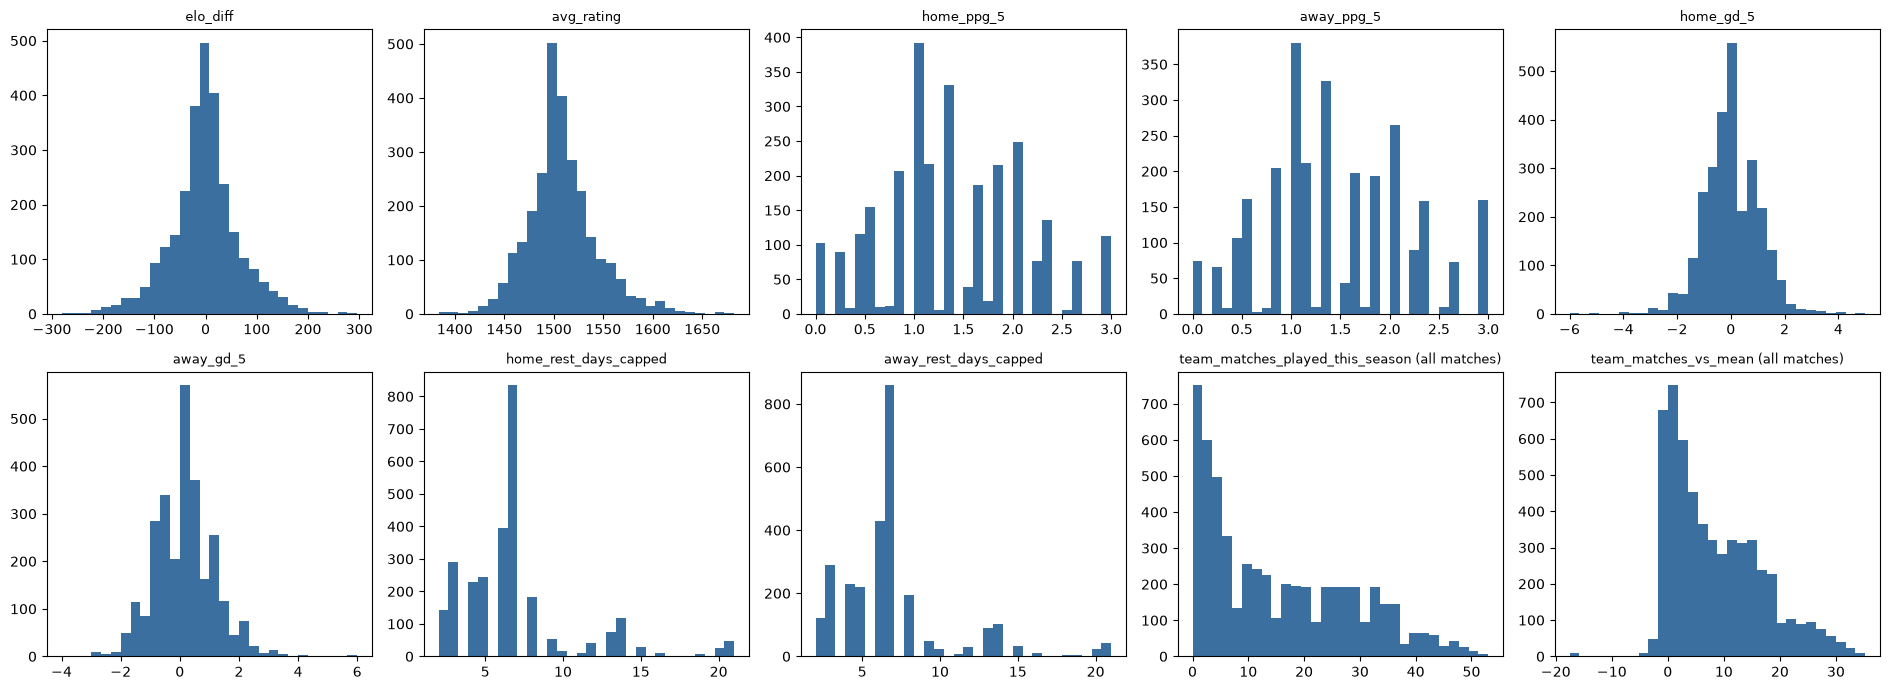

In [6]:
# frequency distributions of every engineered feature, before we hand them to any model.
# team_matches_played_this_season / team_matches_vs_mean come straight from team_log (every
# team-match row, home and away combined, across all competitions) rather than just the home_
# columns -- restricting to home only would silently drop half the observations for no reason.
import matplotlib.pyplot as plt

BLUE = "#3B6FA0"
dist_cols = ["elo_diff", "avg_rating", "home_ppg_5", "away_ppg_5", "home_gd_5", "away_gd_5", "home_rest_days_capped", "away_rest_days_capped"]

fig, axes = plt.subplots(2, 5, figsize=(19, 7))
for ax, col in zip(axes.flat, dist_cols):
    ax.hist(model_df[col], bins=30, color=BLUE)
    ax.set_title(col, fontsize=9)

axes.flat[8].hist(team_log["team_matches_played_this_season"], bins=30, color=BLUE)
axes.flat[8].set_title("team_matches_played_this_season (all matches)", fontsize=9)
axes.flat[9].hist(team_log["team_matches_vs_mean"], bins=30, color=BLUE)
axes.flat[9].set_title("team_matches_vs_mean (all matches)", fontsize=9)

plt.tight_layout()
plt.show()

### Goal difference distributions

How many goals does each side actually score, and what does the match-level goal difference (home - away) look like -- frequency, % share, and cumulative %.

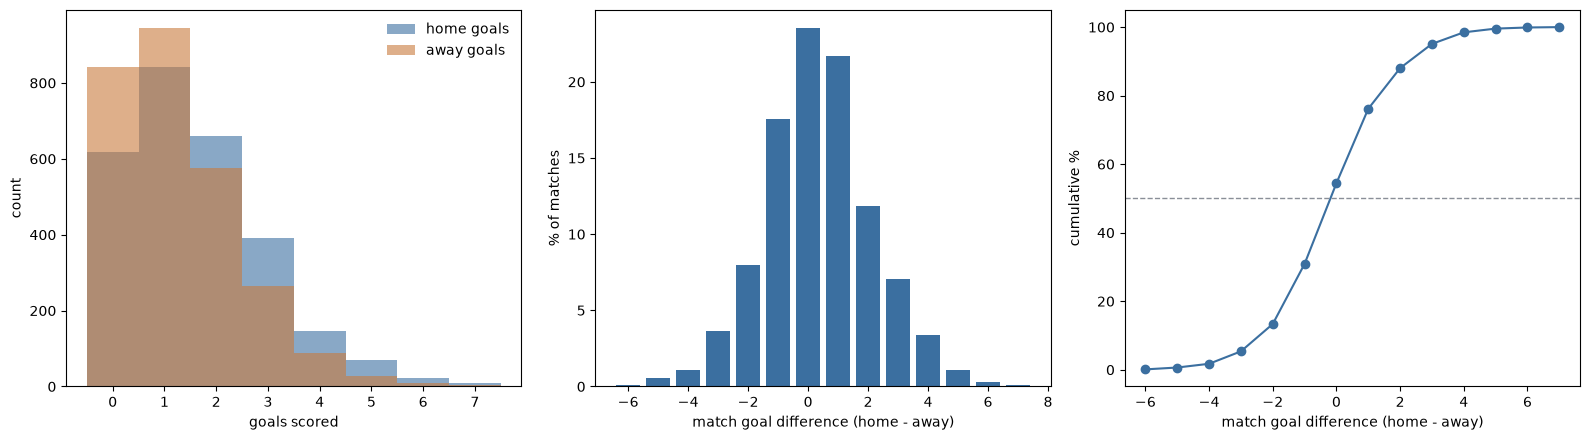

In [7]:
match_goal_diff = valid["home_score"] - valid["away_score"]

# pdf: % of matches at each exact goal difference. cdf: running total, i.e. "% of matches
# with a goal difference of at most this value"
pdf = match_goal_diff.value_counts(normalize=True).sort_index() * 100
cdf = pdf.cumsum()

ORANGE = "#C97A3D"
GRAY = "#8A8F98"

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(valid["home_score"], bins=range(0, 9), color=BLUE, alpha=0.6, label="home goals", align="left")
axes[0].hist(valid["away_score"], bins=range(0, 9), color=ORANGE, alpha=0.6, label="away goals", align="left")
axes[0].set_xlabel("goals scored")
axes[0].set_ylabel("count")
axes[0].legend(frameon=False)

axes[1].bar(pdf.index, pdf.values, color=BLUE)
axes[1].set_xlabel("match goal difference (home - away)")
axes[1].set_ylabel("% of matches")

axes[2].plot(cdf.index, cdf.values, color=BLUE, marker="o")
axes[2].axhline(50, color=GRAY, linestyle="--", linewidth=1)
axes[2].set_xlabel("match goal difference (home - away)")
axes[2].set_ylabel("cumulative %")

plt.tight_layout()
plt.show()

In [8]:
# exact table, plus the specific thresholds that matter for how "close" a match typically is
summary = pd.DataFrame({"count": match_goal_diff.value_counts().sort_index(), "pct": pdf.round(2), "cumulative_pct": cdf.round(2)})
print(summary)
print()
print(f"P(diff == 0), i.e. draw rate: {(match_goal_diff == 0).mean():.1%}")
print(f"P(|diff| <= 1): {(match_goal_diff.abs() <= 1).mean():.1%}")
print(f"P(|diff| <= 2): {(match_goal_diff.abs() <= 2).mean():.1%}")

      count    pct  cumulative_pct
-6.0      3   0.11            0.11
-5.0     15   0.54            0.65
-4.0     30   1.09            1.74
-3.0    100   3.63            5.37
-2.0    220   7.98           13.35
-1.0    484  17.56           30.90
 0.0    649  23.54           54.44
 1.0    599  21.73           76.17
 2.0    327  11.86           88.03
 3.0    195   7.07           95.10
 4.0     93   3.37           98.48
 5.0     30   1.09           99.56
 6.0      9   0.33           99.89
 7.0      3   0.11          100.00

P(diff == 0), i.e. draw rate: 23.5%
P(|diff| <= 1): 62.8%
P(|diff| <= 2): 82.7%


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss
import xgboost as xgb

results = {}

# logistic regression needs scaled features; trees don't
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
proba = log_reg.predict_proba(X_test_scaled)
pred = log_reg.predict(X_test_scaled)
results["LogisticRegression"] = {
    "accuracy": accuracy_score(y_test, pred),
    "log_loss": log_loss(y_test, proba, labels=log_reg.classes_),
}

# shallow-ish trees + a min leaf size, to keep it from just memorizing the training set
random_forest = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=20, random_state=42)
random_forest.fit(X_train, y_train)
proba = random_forest.predict_proba(X_test)
pred = random_forest.predict(X_test)
results["RandomForest"] = {
    "accuracy": accuracy_score(y_test, pred),
    "log_loss": log_loss(y_test, proba, labels=random_forest.classes_),
}

# xgboost wants numeric class labels
label_map = {"away": 0, "draw": 1, "home": 2}
y_train_num = y_train.map(label_map)
y_test_num = y_test.map(label_map)

xgb_model = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, eval_metric="mlogloss", random_state=42)
xgb_model.fit(X_train, y_train_num)
proba = xgb_model.predict_proba(X_test)
pred = xgb_model.predict(X_test)
results["XGBoost"] = {
    "accuracy": accuracy_score(y_test_num, pred),
    "log_loss": log_loss(y_test_num, proba),
}

results_df = pd.DataFrame(results).T
results_df

,accuracy,log_loss
LogisticRegression,0.491039,1.005357
RandomForest,0.501792,1.009098
XGBoost,0.473118,1.050075


### Feature importance -- what's actually earning its place?

Random Forest and XGBoost both expose importance scores natively. Comparing the two (rather than trusting just one) since they can disagree on ties/correlated features.

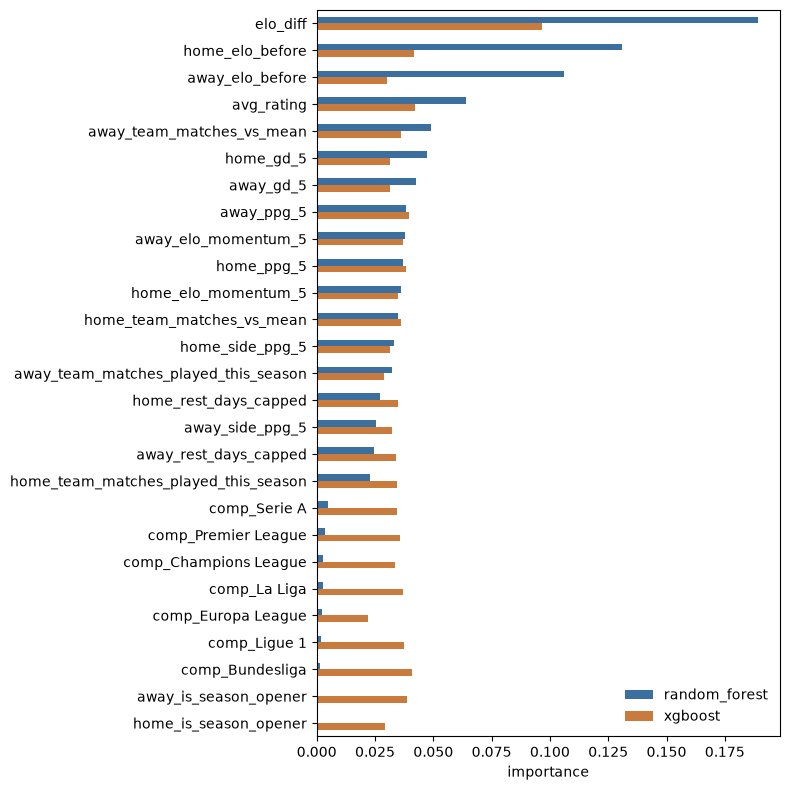

,random_forest,xgboost
elo_diff,0.189195,0.096584
home_elo_before,0.130734,0.041603
away_elo_before,0.106183,0.030326
avg_rating,0.064191,0.042078
away_team_matches_vs_mean,0.049169,0.036161
home_gd_5,0.047191,0.031496
away_gd_5,0.042761,0.031310
away_ppg_5,0.038453,0.039744
away_elo_momentum_5,0.037797,0.037037
home_ppg_5,0.036960,0.038485


In [10]:
importances = pd.DataFrame({
    "random_forest": random_forest.feature_importances_,
    "xgboost": xgb_model.feature_importances_,
}, index=X_train.columns).sort_values("random_forest", ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
importances.plot(kind="barh", ax=ax, color=[BLUE, ORANGE])
ax.invert_yaxis()
ax.set_xlabel("importance")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

importances

In [11]:
# baselines for context: does any of this actually beat doing nothing clever?
majority_class = y_train.value_counts().idxmax()
majority_baseline = (y_test == majority_class).mean()

plain_elo_pred = np.where(model_df.loc[~train_mask, "home_elo_before"] > model_df.loc[~train_mask, "away_elo_before"], "home", "away")
plain_elo_baseline = (y_test.values == plain_elo_pred).mean()

print(f"baseline -- always predict '{majority_class}': {majority_baseline:.1%}")
print(f"baseline -- plain elo, home/away pick only: {plain_elo_baseline:.1%}")

baseline -- always predict 'home': 46.8%
baseline -- plain elo, home/away pick only: 45.3%
